# Evaluating the genre model

Scores the model the ml service loads (`models/genre_classifier.keras`) on the 591 test photos. None of them were
used for training or for picking the network size. Run it after `build_dataset.py` and `train.py`.

In [1]:
import csv

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, cohen_kappa_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from data_files import DATA_DIR, MODEL_PATH, load_labels, load_split
from genres import GENRES

x_train, y_train = load_split("train")
x_test, y_test = load_split("test")
probabilities = tf.keras.models.load_model(MODEL_PATH).predict(x_test, verbose=0)
predicted = probabilities.argmax(axis=1)
top_two = np.argsort(probabilities, axis=1)[:, -2:]

## Accuracy

Top-2 counts a photo as right when its label is one of the model's two most likely genres. The baselines are
always guessing the most common training genre, and logistic regression on the same 8 features.

In [2]:
most_common = np.full_like(y_test, np.bincount(y_train).argmax())
logistic = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(x_train, y_train)
network_right = (predicted == y_test).astype(float)
top_two_right = (top_two == y_test[:, None]).any(axis=1).astype(float)

print(f"Most common genre        {accuracy_score(y_test, most_common):.1%}")
print(f"Logistic regression      {accuracy_score(y_test, logistic.predict(x_test)):.1%}")
print(f"Neural network, top-1    {network_right.mean():.1%}")
print(f"Neural network, top-2    {top_two_right.mean():.1%}")

Most common genre        36.4%
Logistic regression      78.5%
Neural network, top-1    80.9%
Neural network, top-2    95.6%


### Bootstrap intervals

The 591 photos are resampled 10,000 times to get a 95% interval for each accuracy and for the network's lead
over the baselines.

In [3]:
resamples = np.random.default_rng(42).integers(0, len(y_test), size=(10_000, len(y_test)))

def interval(per_photo: np.ndarray) -> str:
    """The mean of a per-photo score, with its 95% bootstrap interval."""
    low, high = np.percentile(per_photo[resamples].mean(axis=1), [2.5, 97.5])
    return f"{per_photo.mean():6.1%}   95% interval {low:.1%} to {high:.1%}"

logistic_right = (logistic.predict(x_test) == y_test).astype(float)
print("Top-1 accuracy              ", interval(network_right))
print("Top-2 accuracy              ", interval(top_two_right))
print("Lead over logistic          ", interval(network_right - logistic_right))
print("Lead over most common genre ", interval(network_right - (most_common == y_test)))

Top-1 accuracy                80.9%   95% interval 77.7% to 84.1%
Top-2 accuracy                95.6%   95% interval 93.9% to 97.1%
Lead over logistic             2.4%   95% interval 0.0% to 4.7%
Lead over most common genre   44.5%   95% interval 39.8% to 49.4%


## Per genre

In [4]:
print(classification_report(y_test, predicted, target_names=GENRES, digits=3, zero_division=0))

              precision    recall  f1-score   support

   EDM_CHILL      0.811     0.754     0.782       114
    EDM_DROP      0.884     0.735     0.803        83
   CINEMATIC      0.796     0.837     0.816       215
       HOUSE      0.795     0.844     0.818       179

    accuracy                          0.809       591
   macro avg      0.822     0.793     0.805       591
weighted avg      0.811     0.809     0.808       591



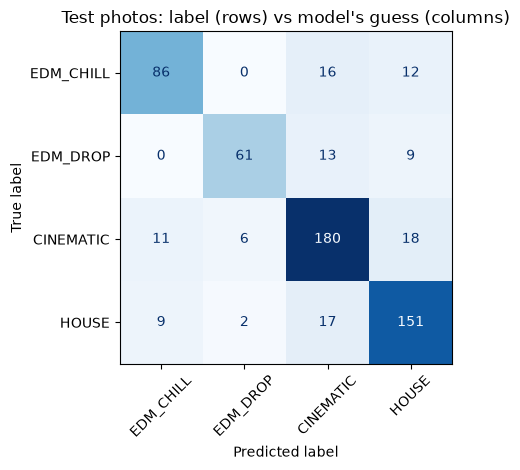

In [5]:
ConfusionMatrixDisplay.from_predictions(y_test, predicted, display_labels=GENRES,
                                        xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Test photos: label (rows) vs model's guess (columns)")
plt.tight_layout()
plt.show()

## Label consistency

150 random photos have a second set of labels in `data/second_labels.csv`. How often the two sets agree is a
rough ceiling for any model trained on these labels.

In [6]:
labels = load_labels()
with (DATA_DIR / "second_labels.csv").open(newline="") as file:
    second = {row["image"]: row["genre"] for row in csv.DictReader(file)}

first_labels = [labels[image] for image in second]
second_labels = list(second.values())
print(f"{len(second)} photos with two labels: the two label sets agree on "
      f"{accuracy_score(first_labels, second_labels):.1%}, Cohen's kappa {cohen_kappa_score(first_labels, second_labels):.2f}")

149 photos with two labels: the two label sets agree on 74.5%, Cohen's kappa 0.64


## Conclusions

The model gets 80.9% of the test photos right (95% interval 77.7% to 84.1%), and the label is one of its top two
guesses 95.6% of the time. Logistic regression on the same features gets 78.5%, so most of the accuracy comes from
the features rather than the network.

The model already agrees with the labels more often than the two label sets agree with each other (81% vs 74%),
so more tuning on this data won't get much further. Better features would, for example colour per region of the
image or a pretrained image embedding.

Most mistakes are between neighbouring moods, mainly CINEMATIC with HOUSE or EDM_CHILL.